Loaded 900 spins


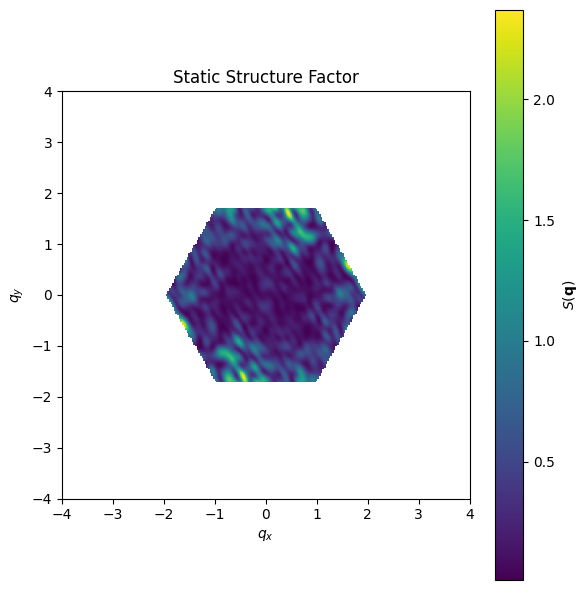

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS
# =========================
filename = "spin_dynamics_J_1_K_0.txt"   # <-- your file name
select_t = None              # e.g. 1000 to pick only t=1000
                            # None = use all rows (average-like)

nq = 250                     # q-grid resolution

# =========================
# LOAD DATA
# =========================

data = np.loadtxt(filename, delimiter=None)

t = data[:,0].astype(int)
i = data[:,1].astype(int)
j = data[:,2].astype(int)
S = data[:,3:6]

# optionally filter one MC step
if select_t is not None:
    mask = (t == select_t)
    i = i[mask]
    j = j[mask]
    S = S[mask]

# =========================
# BUILD HONEYCOMB POSITIONS
# =========================

# lattice vectors
a1 = np.array([1.0, 0.0])
a2 = np.array([0.5, np.sqrt(3)/2])

# two sublattices per (i,j)
delta = np.array([0.0, 1.0/np.sqrt(3)])

# infer sublattice: even rows = A, odd rows = B
r = []
for ii, jj in zip(i, j):
    R = ii*a1 + jj*a2
    if (ii + jj) % 2 == 0:
        r.append(R)          # A site
    else:
        r.append(R + delta)  # B site

r = np.array(r)
N = len(r)

print(f"Loaded {N} spins")

# =========================
# STRUCTURE FACTOR
# =========================

def compute_structure_factor(r, S, nq=200):
    qx = np.linspace(-4, 4, nq)
    qy = np.linspace(-4, 4, nq)
    Sq = np.zeros((nq, nq))

    for ix, qxi in enumerate(qx):
        for iy, qyi in enumerate(qy):
            q = np.array([qxi, qyi])
            phase = np.exp(1j * (r @ q))
            Mq = np.sum(S * phase[:, None], axis=0)
            Sq[iy, ix] = np.real(np.dot(Mq, np.conj(Mq))) / len(r)

    return qx, qy, Sq

# =========================
# HEXAGON MASK
# =========================

def hexagon_mask(qx, qy):
    mask = np.zeros((len(qy), len(qx)), dtype=bool)
    for ix, x in enumerate(qx):
        for iy, y in enumerate(qy):
            X = abs(x)
            Y = abs(y)
            if (Y < np.sqrt(3)) and (np.sqrt(3)*X + Y < 2*np.sqrt(3)):
                mask[iy, ix] = True
    return mask

# =========================
# RUN + PLOT
# =========================

qx, qy, Sq = compute_structure_factor(r, S, nq=nq)
mask = hexagon_mask(qx, qy)
Sq = np.where(mask, Sq, np.nan)

plt.figure(figsize=(6,6))
plt.imshow(Sq, extent=[qx.min(),qx.max(),qy.min(),qy.max()],
           origin='lower', aspect='equal')
plt.colorbar(label=r"$S(\mathbf{q})$")
plt.xlabel(r"$q_x$")
plt.ylabel(r"$q_y$")
plt.title("Static Structure Factor")
plt.tight_layout()
plt.show()


In [4]:
import numpy as np

def calculate_structure_factor(spins, L):
    """
    Calculates S(q) from a single 2D spin configuration.
    
    Args:
        spins (ndarray): 2D array of spin values (e.g., shape L x L).
        L (int): Linear system size.
        
    Returns:
        ndarray: 2D array of S(q) values for the Brillouin zone.
    """
    # 1. Compute the 2D Fast Fourier Transform (FFT) of the spin grid
    # This is mathematically equivalent to \sum_r S_r * exp(-i q.r)
    # for all allowed q-vectors simultaneously.
    sq_fft = np.fft.fft2(spins)
    
    # 2. Calculate intensity |S(q)|^2 / N
    # np.abs(sq_fft)**2 gives the magnitude squared
    sq = (np.abs(sq_fft)**2) / (L * L)
    
    # 3. Use fftshift to center q=(0,0) in the middle of the plot
    return np.fft.fftshift(sq)

# --- Example Usage ---
L = 32  # System size
# Mock data: A perfectly ordered ferromagnetic state (all spins = 1)
ferro_state = np.ones((L, L))

# Mock data: A random paramagnetic state
para_state = np.random.choice([1, -1], size=(L, L))

# Calculate S(q)
sq_ferro = calculate_structure_factor(ferro_state, L)
sq_para = calculate_structure_factor(para_state, L)

print(f"Peak value for Ferromagnet (should be N={L*L}):", np.max(sq_ferro))
print(f"Average value for Paramagnet (should be ~1):", np.mean(sq_para))


Peak value for Ferromagnet (should be N=1024): 1024.0
Average value for Paramagnet (should be ~1): 1.0
